# AI2002 - Group 5 - Joint Fine-Grained Opinion Extraction and Overall Rating Prediction from Real-World Hotel Reviews

## 0. Cài đặt môi trường (Environment Setup & Auto-install)

Với dự án nghiên cứu về **Review Chatbot for Hotel Question Answering**, hệ thống được thiết lập cơ chế **tự động kiểm tra và cài đặt thư viện** từ file `requirements.txt` vào môi trường ảo (`.venv`):

1. **Tự động nhận diện môi trường ảo**: Cài đặt trực tiếp vào Python Kernel (`sys.executable`) đang chạy trong notebook.
2. **Kiểm tra thông minh**: Chỉ cài đặt các gói còn thiếu từ `requirements.txt`, tránh tốn thời gian khi chạy lại notebook.
3. **Các thư viện chính**:
   - **Pandas / NumPy**: Xử lý dữ liệu bảng quy mô lớn và tính toán đại số ma trận.
   - **PyArrow**: Engine C++ tối ưu hóa nạp dữ liệu siêu tốc và xử lý định dạng Parquet.
   - **SQLite3**: Cơ sở dữ liệu quan hệ cục bộ lưu trữ dữ liệu có cấu trúc.
   - **Matplotlib / Seaborn**: Trực quan hóa dữ liệu EDA và biểu đồ phân tích.
   - **Scikit-learn / NLTK**: Xử lý ngôn ngữ tự nhiên (NLP), TF-IDF và thuật toán Cosine Similarity.
   - **Tqdm / Ipywidgets**: Thanh tiến trình hiển thị trực quan trong quá trình xử lý văn bản.


In [2]:
import os
import re
import sqlite3
import pandas as pd
import numpy as np
import pyarrow as pa
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import nltk

# Tự động tải các gói tài nguyên cần thiết cho NLTK 
for res in ['punkt', 'punkt_tab', 'stopwords']:
    try:
        nltk.download(res, quiet=True)
    except Exception:
        pass

# Hiển thị bảng phiên bản chi tiết các thư viện
print(f"{'Thư viện':<20} {'Phiên bản':>15}")
print("-" * 37)
print(f"{'Python':<20} {os.sys.version.split()[0]:>15}")
print(f"{'Pandas':<20} {pd.__version__:>15}")
print(f"{'PyArrow':<20} {pa.__version__:>15}")
print(f"{'NumPy':<20} {np.__version__:>15}")
print(f"{'Matplotlib':<20} {matplotlib.__version__:>15}")
print(f"{'Seaborn':<20} {sns.__version__:>15}")
print(f"{'Scikit-learn':<20} {sklearn.__version__:>15}")
print(f"{'NLTK':<20} {nltk.__version__:>15}")
print(f"{'SQLite3':<20} {sqlite3.sqlite_version:>15}")
print(f"{'Regex (re)':<20} {re.__version__ if hasattr(re, '__version__') else 'built-in':>15}")

# Khởi tạo thư mục và kết nối SQLite
db_dir = 'Data' if os.path.exists('Data') else 'Data'
os.makedirs(db_dir, exist_ok=True)
db_path = os.path.join(db_dir, 'chatbot.db')
conn = sqlite3.connect(db_path)

print(f"\nSQLite đã sẵn sàng tại: {db_path}")
print("--- Môi trường đã được khởi tạo thành công ---")


Thư viện                   Phiên bản
-------------------------------------
Python                       3.12.14
Pandas                         3.0.5
PyArrow                       25.0.1
NumPy                          2.5.3
Matplotlib                    3.11.1
Seaborn                       0.13.2
Scikit-learn                   1.9.0
NLTK                          3.10.3
SQLite3                       3.53.4
Regex (re)                     2.2.1

SQLite đã sẵn sàng tại: Data/chatbot.db
--- Môi trường đã được khởi tạo thành công ---


## 1. Liên kết Dataset

### 1.1 CHỈ CHẠY TRÊN GOOGLE COLAB - không chạy trên VSCode (IDE) để tránh lỗi

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Đường dẫn thư mục chứa dataset trên Drive của bạn (vui lòng cập nhật nếu cần)
drive_path = '/content/drive/MyDrive/Study/FPTU/FU_4_FA26/DAP391m/DAP391m_AI2002_Group 7/2 - Dataset'
dataset_name = 'tripadvisor_review_hotel_dataset.csv'

# Tạo thư mục local 'Data' nếu chưa có
os.makedirs('Data', exist_ok=True)

# Kiểm tra và tạo liên kết (symlink) hoặc copy file vào thư mục Data local
if os.path.exists(os.path.join(drive_path, dataset_name)):
    local_file = os.path.join('Data', dataset_name)
    if not os.path.exists(local_file):
        # Sử dụng symlink để tiết kiệm dung lượng và thời gian
        os.symlink(os.path.join(drive_path, dataset_name), local_file)
        print(f"Đã liên kết thành công dataset từ Google Drive vào {local_file}")
    else:
        print(f"Tệp dataset đã sẵn sàng tại {local_file}")
else:
    print(f"CẢNH BÁO: Không tìm thấy tệp {dataset_name} tại {drive_path}. Vui lòng kiểm tra lại đường dẫn.")

### 1.2 Nhập và Kiểm tra Dataset (Dataset Loading & Exploration)

Trong phần này, nhóm áp dụng giải pháp **Tối ưu hóa nạp dữ liệu quy mô lớn** (~740MB, >780.000 dòng):
1. **Cơ chế Caching thông minh (Parquet Optimization)**:
   - Hệ thống tự động kiểm tra định dạng nhị phân dạng cột **Parquet** (`tripadvisor_review_hotel_dataset.parquet`). Nếu chưa tồn tại, chương trình sẽ tự động đọc CSV với engine **PyArrow** đa luồng và tạo cache Parquet (chuẩn nén Snappy).
2. **Kiểm tra cấu trúc và các trường thông tin quan trọng**:
   - **Thông tin cơ sở lưu trú**: `hotel_name`, `hotel_province`, `hotel_address`, `hotel_star`.
   - **Điểm đánh giá và các khía cạnh dịch vụ**: `normalized_score`, `Value`, `Rooms`, `Location`, `Cleanliness`, `Service`, `Sleep_Quality`.
   - **Dữ liệu văn bản phục vụ Chatbot Hỏi Đáp (QA)**: `normalized_title` (tiêu đề đánh giá), `normalized_content` (nội dung đánh giá chi tiết), `Word_count`, `language_code`, `language`.
   - **Bối cảnh chuyến đi & Thời gian**: `trip_type`, `Date`, `month`, `year`.


In [3]:
import os
import time
import pandas as pd

# Tạo thư mục lưu trữ biểu đồ trực quan hóa nếu chưa tồn tại
os.makedirs('Data/charts_img', exist_ok=True)

# Đường dẫn các file dữ liệu
csv_path = 'Data/tripadvisor_review_hotel_dataset.csv'
parquet_path = 'Data/tripadvisor_review_hotel_dataset.parquet'

start_time = time.time()

# Chiến lược nạp dữ liệu tối ưu với Parquet Cache
if os.path.exists(parquet_path):
    print(f"Tìm thấy cache Parquet: {parquet_path}")
    print("Đang nạp dữ liệu từ file Parquet...")
    df = pd.read_parquet(parquet_path)
    load_time = time.time() - start_time
    print(f"Nạp dữ liệu hoàn tất trong: {load_time:.2f} giây")
elif os.path.exists(csv_path):
    print(f"Tìm thấy file dataset CSV: {csv_path}")
    print("Đang đọc CSV và tạo cache Parquet...")
    df = pd.read_csv(csv_path, engine='pyarrow', encoding='utf-8')
    read_time = time.time() - start_time
    print(f"Đọc CSV thành công trong {read_time:.2f} giây")
    
    print("Đang lưu cache Parquet...")
    df.to_parquet(parquet_path, engine='pyarrow', index=False)
    total_time = time.time() - start_time
    print(f"Đã tạo cache Parquet thành công tại: {parquet_path} (Thời gian: {total_time:.2f}s)")
else:
    raise FileNotFoundError(f"Không tìm thấy dataset tại '{csv_path}' hoặc '{parquet_path}'.")

# Thống kê tập dữ liệu
ram_usage_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
active_path = parquet_path if os.path.exists(parquet_path) else csv_path
file_size_mb = os.path.getsize(active_path) / (1024 ** 2)

print(f"\nKích thước tập dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print(f"Dung lượng file trên ổ cứng: {file_size_mb:.2f} MB")
print(f"Dung lượng RAM chiếm: {ram_usage_mb:.2f} MB")
print("\nCác cột dữ liệu:")
print(list(df.columns))

# Hiển thị 5 dòng đầu tiên
print("\nXem trước 5 dòng đầu tiên:")
display(df.head())


Tìm thấy cache Parquet: Data/tripadvisor_review_hotel_dataset.parquet
Đang nạp dữ liệu từ file Parquet...
Nạp dữ liệu hoàn tất trong: 1.95 giây

Kích thước tập dữ liệu: 782,584 dòng x 25 cột
Dung lượng file trên ổ cứng: 252.52 MB
Dung lượng RAM chiếm: 824.72 MB

Các cột dữ liệu:
['id_url', 'Date', 'month', 'year', 'month_str', 'normalized_score', 'trip_type', 'hotel_province', 'Value', 'Rooms', 'Location', 'Cleanliness', 'Service', 'Sleep_Quality', 'normalized_content', 'normalized_title', 'Word_count', 'language_code', 'language', 'nationality', 'hotel_name', 'hotel_address', 'source', 'hotel_star', 'link']

Xem trước 5 dòng đầu tiên:


,id_url,Date,month,year,month_str,normalized_score,trip_type,hotel_province,Value,Rooms,...,normalized_title,Word_count,language_code,language,nationality,hotel_name,hotel_address,source,hotel_star,link
0,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2023-07,7,2023,Jul,5.0,Traveled as a couple,Hà Nội,5.0,NaN,...,Very good hotel,44,en,English,no_info,20 hotel and apartment,"93A Đội Cấn, Ba Dinh, Hà Nội 100000 Việt Nam",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...
1,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2023-04,4,2023,Apr,4.0,Traveled as a couple,Hà Nội,4.0,NaN,...,BUEN ALOJAMIENTO QUE GANARIA MUCHO MEJORANDO E...,431,es,Spanish,Spain,20 hotel and apartment,"93A Đội Cấn, Ba Dinh, Hà Nội 100000 Việt Nam",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...
2,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2023-05,5,2023,May,5.0,Traveled on business,Hà Nội,5.0,NaN,...,Great place in Cau Giay,71,en,English,Vietnam,22land residence hotel,"02 Nguyen Dinh Hoan, Cau Giay, Hà Nội 100000 V...",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...
3,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2023-04,4,2023,Apr,5.0,Traveled solo,Hà Nội,NaN,NaN,...,TRẢI NGHIỆM TỐT,45,vi,Vietnamese,Vietnam,22land residence hotel,"02 Nguyen Dinh Hoan, Cau Giay, Hà Nội 100000 V...",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...
4,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2022-12,12,2022,Dec,5.0,Traveled with family,Hà Nội,NaN,NaN,...,Perfect stay,44,en,English,Netherlands,22land residence hotel,"02 Nguyen Dinh Hoan, Cau Giay, Hà Nội 100000 V...",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...


## 2. Data Analysis with SQL & Python   

### 2.1. Đưa dữ liệu từ DataFrame vào bảng SQLite để truy vấn.  

In [4]:
table_name = 'hotel_reviews'

print(f"Đang ghi DataFrame vào bảng SQLite '{table_name}'...")
df.to_sql(table_name, conn, if_exists='replace', index=False)
print(f"Đã ghi {len(df):,} dòng vào bảng '{table_name}' thành công.")

print(pd.read_sql_query(f"SELECT * FROM {table_name} LIMIT 5", conn))

Đang ghi DataFrame vào bảng SQLite 'hotel_reviews'...
Đã ghi 782,584 dòng vào bảng 'hotel_reviews' thành công.
                                              id_url     Date  month  year  \
0  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2023-07      7  2023   
1  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2023-04      4  2023   
2  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2023-05      5  2023   
3  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2023-04      4  2023   
4  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2022-12     12  2022   

  month_str  normalized_score             trip_type hotel_province  Value  \
0       Jul               5.0  Traveled as a couple       Hà Nội    5.0   
1       Apr               4.0  Traveled as a couple       Hà Nội    4.0   
2       May               5.0  Traveled on business       Hà Nội    5.0   
3       Apr               5.0         Traveled solo       Hà Nội    NaN   
4       Dec               5.0  Trav

### 2.2. SQL Queries để giải quyết 3 RQ.

Dự án bao gồm 5 Research Questions bao gồm:

RQ1: CRAM-ABSA có cải thiện joint ABSA + rating prediction so với các baseline single-task/multi-task đơn giản trên cùng Hotel-Disjoint split hay không?

***Does CRAM-ABSA improve joint ABSA and rating prediction compared to simple single-task/multi-task baselines under the same Hotel-Disjoint split?***

RQ2: Continuous Rating Head có giúp biểu diễn toàn cục và cải thiện extraction hay chỉ cải thiện riêng rating?

***Does the Continuous Rating Head facilitate global representation and improve extraction, or does it solely enhance rating prediction?***

RQ3: Conflict Attenuation Gating có thực sự giúp các review mixed/conflicting sentiment hay không?

***Does the Conflict Attenuation Gating mechanism genuinely assist with reviews containing mixed or conflicting sentiments?***

RQ4: Tại sao Overlap F1 cao nhưng Exact F1 thấp, và lỗi chủ yếu nằm ở boundary, aspect mapping hay sentiment?

***Why is the Overlap F1 score high while the Exact F1 score is low, and do the errors primarily stem from boundaries, aspect mapping, or sentiment?***

RQ5: Hotel-Disjoint evaluation thay đổi hiệu năng thế nào so với random review split?

***How does performance under the Hotel-Disjoint evaluation differ from that of a random review split?***

In [ ]:
#Link to RQ1 Query 1
query = "SELECT normalized_score, COUNT(*) as count FROM hotel_reviews GROUP BY normalized_score ORDER BY normalized_score"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ1 Query 2
query = "SELECT trip_type, AVG(normalized_score) as avg_score FROM hotel_reviews WHERE trip_type IS NOT NULL GROUP BY trip_type"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ1 Query 3
query = "SELECT hotel_star, COUNT(*) as review_count FROM hotel_reviews GROUP BY hotel_star"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ1 Query 4
query = "SELECT normalized_score, AVG(Word_count) as avg_word_count FROM hotel_reviews GROUP BY normalized_score"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ2 Query 5
query = "SELECT normalized_score, AVG(Service) as avg_service FROM hotel_reviews GROUP BY normalized_score"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ2 Query 6
query = "SELECT normalized_score, AVG(Cleanliness) as avg_cleanliness FROM hotel_reviews GROUP BY normalized_score"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ2 Query 7
query = "SELECT normalized_score, AVG(Word_count) FROM hotel_reviews WHERE normalized_score IN (1, 5) GROUP BY normalized_score"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ2 Query 8
query = "SELECT normalized_score, AVG(Rooms) as avg_rooms, AVG(Location) as avg_loc FROM hotel_reviews GROUP BY normalized_score"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ3 Query 9
query = "SELECT COUNT(*) as conflict_count FROM hotel_reviews WHERE normalized_score = 5 AND Service <= 2"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ3 Query 10
query = "SELECT COUNT(*) FROM hotel_reviews WHERE normalized_score = 1 AND Location = 5"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ3 Query 11
query = "SELECT AVG(Word_count) FROM hotel_reviews WHERE (Value >= 4 AND Service <= 2) OR (Value <= 2 AND Service >= 4)"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ3 Query 12
query = "SELECT (COUNT(*) * 100.0 / (SELECT COUNT(*) FROM hotel_reviews)) as null_percentage FROM hotel_reviews WHERE Service IS NULL OR Cleanliness IS NULL"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ4 Query 13
query = "SELECT COUNT(*) FROM hotel_reviews WHERE LENGTH(normalized_title) < 10 AND Word_count > 100"
pd.read_sql_query(query, conn)

In [ ]:

#Link to RQ4 Query 14
query = "SELECT language, COUNT(*) as count FROM hotel_reviews GROUP BY language ORDER BY count DESC LIMIT 5"
pd.read_sql_query(query, conn)


In [ ]:
#Link to RQ4 Query 15
query = "SELECT COUNT(*) FROM hotel_reviews WHERE Sleep_Quality IS NOT NULL AND Service IS NULL AND Cleanliness IS NULL"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ4 Query 16
query = "SELECT language, AVG(Word_count) FROM hotel_reviews GROUP BY language HAVING COUNT(*) > 1000"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ5 Query 17
query = "SELECT hotel_province, COUNT(*) as count FROM hotel_reviews GROUP BY hotel_province ORDER BY count DESC"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ5 Query 18
query = "SELECT COUNT(DISTINCT hotel_name) FROM hotel_reviews"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ5 Query 19
query = "SELECT year, COUNT(*) FROM hotel_reviews GROUP BY year ORDER BY year"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ5 Query 20
query = "SELECT hotel_name, COUNT(*) as review_count FROM hotel_reviews GROUP BY hotel_name ORDER BY review_count DESC LIMIT 10"
pd.read_sql_query(query, conn)

## 3. EDA & Data Cleaning

Trong mục này, nhóm tiến hành phân tích khám phá dữ liệu (Exploratory Data Analysis - EDA), nhận diện các vấn đề về phân phối và ngoại lai (Outliers), sau đó thực hiện quy trình làm sạch dữ liệu (Data Cleaning) chuẩn mực theo các nguyên tắc Khoa học Dữ liệu (Data Science) và Xử lý Ngôn ngữ Tự nhiên (NLP).

### 3.1. Khám phá Dữ liệu (Exploratory Data Analysis - EDA)

Các bước thực hiện:
1. **Kiểm tra kích thước & Kiểu dữ liệu**: Xác định cấu trúc số chiều và kiểu dữ liệu từng cột.
2. **Kiểm tra tỷ lệ giá trị thiếu (Missing Values)**: Phân tích mức độ khuyết của từng thuộc tính để đưa ra chiến lược xử lý phù hợp.
3. **Thống kê mô tả (Descriptive Statistics)**: Đánh giá độ biến thiên, khoảng tứ phân vị và phân phối của các biến số.

In [5]:
# 1. Kiểm tra kích thước tổng quan
print(f"Kích thước tập dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột")

# 2. Bảng thống kê chi tiết giá trị khuyết thiếu (Missing Values)
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Tỷ lệ thiếu (%)': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Số lượng thiếu'] > 0].sort_values(by='Tỷ lệ thiếu (%)', ascending=False)

print("\n--- Bảng thống kê các thuộc tính có giá trị khuyết thiếu ---")
display(missing_df)

# 3. Thống kê mô tả các biến số (Numerical Features Summary)
print("\n--- Thống kê mô tả các thuộc tính số (Numerical Summary) ---")
display(df.describe().T.round(2))

# 4. Thống kê sơ bộ các biến phân loại chính
print("\n--- Thống kê nhanh các thuộc tính phân loại chính ---")
for col in ['hotel_star', 'trip_type', 'language']:
    print(f"\nPhân phối thuộc tính '{col}':")
    display(df[col].value_counts(dropna=False).head(5))

Kích thước tập dữ liệu: 782,584 dòng x 25 cột

--- Bảng thống kê các thuộc tính có giá trị khuyết thiếu ---


,Số lượng thiếu,Tỷ lệ thiếu (%)
Sleep_Quality,774935,99.02
Cleanliness,774847,99.01
Rooms,774676,98.99
Location,769745,98.36
Value,769574,98.34
Service,758182,96.88
trip_type,722122,92.27
normalized_title,276,0.04
hotel_name,4,0.00



--- Thống kê mô tả các thuộc tính số (Numerical Summary) ---


,count,mean,std,min,25%,50%,75%,max
month,782584.0,6.34,3.53,1.0,3.0,6.0,9.0,12.0
year,782584.0,2017.85,2.17,2015.0,2016.0,2018.0,2019.0,2023.0
normalized_score,782584.0,4.48,0.95,1.0,4.0,5.0,5.0,5.0
Value,13010.0,4.20,1.24,1.0,4.0,5.0,5.0,5.0
Rooms,7908.0,3.89,1.26,1.0,3.0,4.0,5.0,5.0
Location,12839.0,4.36,1.00,1.0,4.0,5.0,5.0,5.0
Cleanliness,7737.0,4.00,1.24,1.0,3.0,4.0,5.0,5.0
Service,24402.0,4.10,1.28,1.0,4.0,5.0,5.0,5.0
Sleep_Quality,7649.0,4.03,1.23,1.0,3.0,4.0,5.0,5.0
Word_count,782584.0,79.40,48.61,1.0,45.0,67.0,113.0,2408.0



--- Thống kê nhanh các thuộc tính phân loại chính ---

Phân phối thuộc tính 'hotel_star':


hotel_star
3-star    253731
4-star    186510
5-star    139088
0-star    103758
2-star     85164
Name: count, dtype: int64


Phân phối thuộc tính 'trip_type':


trip_type
NaN                      722122
Traveled as a couple      22671
Traveled with friends     13097
Traveled with family      10897
Traveled solo             10095
Name: count, dtype: int64


Phân phối thuộc tính 'language':


language
English       527338
Vietnamese     48396
Korean         42547
French         38770
German         25736
Name: count, dtype: int64

### 3.2. Phân tích & Nhận diện Ngoại lai (Outlier Detection & Domain Validity)

#### 📌 Phân tích bản chất theo miền bài toán (Domain Context):
1. **Thang điểm đánh giá (`normalized_score` & các sub-ratings)**:
   - Thang điểm TripAdvisor chuẩn là từ **1.0 đến 5.0 sao**.
   - Dữ liệu thực tế có xu hướng lệch phải (đa phần người dùng đánh giá 4.0 - 5.0 sao, trung bình ~4.48). Khi vẽ boxplot thông thường, các điểm 1.0 và 2.0 sẽ bị gán nhãn là "outlier" (chấm tròn) do nằm ngoài khoảng $1.5 \times IQR$.
   - **LƯU Ý KHOA HỌC**: Đánh giá 1.0 và 2.0 sao **KHÔNG PHẢI LÀ NGOẠI LAI LỖI CẦN LOẠI BỎ**. Đây là các phản hồi tiêu cực chân thực (negative reviews) phản ánh phàn nàn, mâu thuẫn dịch vụ của khách hàng. Chúng là dữ liệu vô cùng quan trọng để mô hình AI học cách phát hiện khía cạnh tiêu cực (như nghiên cứu trong CRAM-ABSA). Ta chỉ kiểm tra xem có điểm nào vượt ngoài miền $[1.0, 5.0]$ hay không.
2. **Độ dài bài đánh giá (`Word_count`)**:
   - Kiểm tra các review bất thường: Quá ngắn (1 từ, vô nghĩa hoặc spam) hoặc quá dài (>500 - 2.000 từ) để có phương án cắt/xử lý thích hợp khi đưa vào mô hình Transformer (DeBERTa-v3).
3. **Năm đánh giá (`year`)**:
   - Đảm bảo các năm nằm trong khoảng thời gian thu thập hợp lý (2015 - 2023).

Số lượng bản ghi có điểm rating ngoài [1.0, 5.0]: 0
Số lượng bản ghi có năm đánh giá ngoài [2010, 2025]: 0

Phân vị độ dài từ (Word_count):
 - Phân vị 1% (rất ngắn): 1 từ
 - Median (50%): 67 từ
 - Phân vị 99% (rất dài): 181 từ
 - Tối đa: 2408 từ


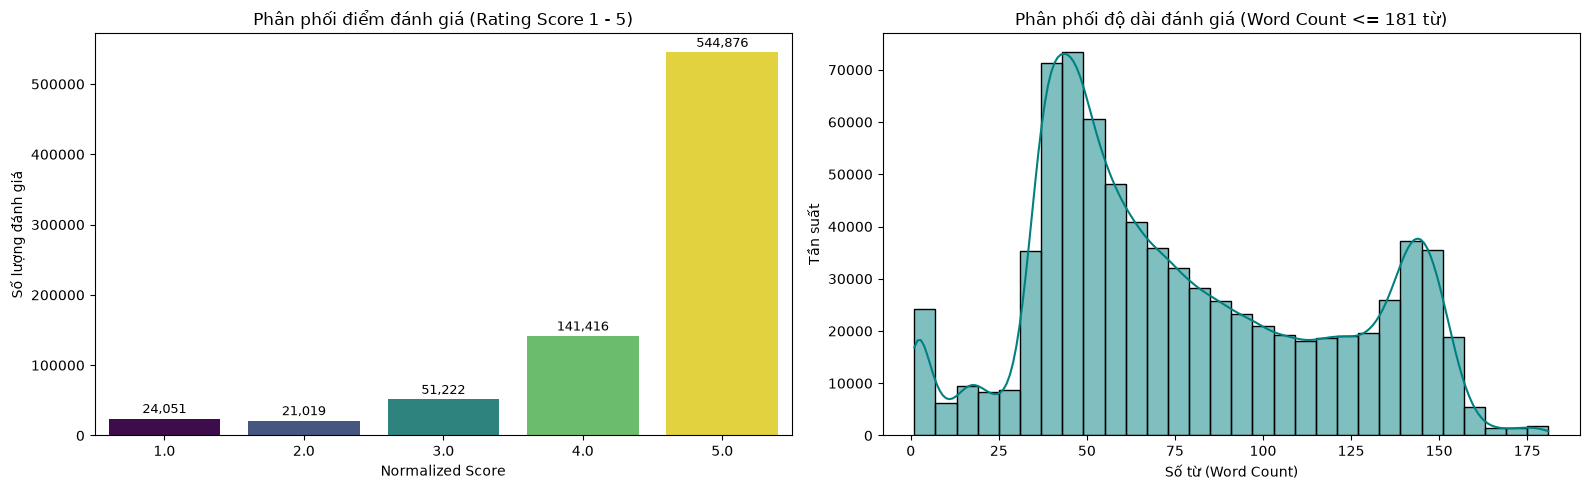

In [7]:
# 1. Kiểm tra tính hợp lệ của miền giá trị (Domain Validity Check)
invalid_scores = df[(df['normalized_score'] < 1.0) | (df['normalized_score'] > 5.0)]
invalid_years = df[(df['year'] < 2010) | (df['year'] > 2025)]
print(f"Số lượng bản ghi có điểm rating ngoài [1.0, 5.0]: {len(invalid_scores)}")
print(f"Số lượng bản ghi có năm đánh giá ngoài [2010, 2025]: {len(invalid_years)}")

# 2. Phân tích độ dài văn bản (Word_count)
print(f"\nPhân vị độ dài từ (Word_count):")
print(f" - Phân vị 1% (rất ngắn): {df['Word_count'].quantile(0.01):.0f} từ")
print(f" - Median (50%): {df['Word_count'].median():.0f} từ")
print(f" - Phân vị 99% (rất dài): {df['Word_count'].quantile(0.99):.0f} từ")
print(f" - Tối đa: {df['Word_count'].max()} từ")

# 3. Trực quan hóa phân phối điểm rating và độ dài đánh giá
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ 1: Phân phối điểm số normalized_score
sns.countplot(ax=axes[0], x='normalized_score', data=df, hue='normalized_score', palette='viridis', legend=False)
axes[0].set_title("Phân phối điểm đánh giá (Rating Score 1 - 5)")
axes[0].set_xlabel("Normalized Score")
axes[0].set_ylabel("Số lượng đánh giá")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='baseline', fontsize=9, xytext=(0, 4), 
                     textcoords='offset points')

# Biểu đồ 2: Phân phối độ dài văn bản (Word_count cắt ở quantile 99% để quan sát)
q99 = df['Word_count'].quantile(0.99)
sns.histplot(ax=axes[1], data=df[df['Word_count'] <= q99], x='Word_count', bins=30, kde=True, color='teal')
axes[1].set_title(f"Phân phối độ dài đánh giá (Word Count <= {int(q99)} từ)")
axes[1].set_xlabel("Số từ (Word Count)")
axes[1].set_ylabel("Tần suất")

plt.tight_layout()
plt.savefig('Data/charts_img/32_outliers_distribution.png', dpi=300)
plt.show()

### 3.3. Tiền xử lý & Làm sạch Dữ liệu (Data Cleaning)

Quy trình làm sạch được thiết kế chuẩn mực theo nguyên tắc khoa học:

1. **Xử lý trùng lặp (Duplicates)**:
   - Loại bỏ các dòng trùng lặp toàn bộ nội dung (`drop_duplicates()`).
2. **Xử lý giá trị khuyết (Missing Values Imputation & Handling)**:
   - **`hotel_name` (thiếu 4 dòng - 0.0005%)**: Loại bỏ 4 dòng này (`dropna(subset=['hotel_name'])`), vì review không có tên khách sạn không có giá trị truy vấn/huấn luyện cho Chatbot. Tuyệt đối không điền `mode()` vì sẽ gán bừa review vô danh vào khách sạn lớn nhất.
   - **`normalized_title` (thiếu 276 dòng - 0.035%)**: Điền chuỗi rỗng `""` thay vì điền `mode()` (tránh gán nhãn rập khuôn hàng trăm review mang tiêu đề của người khác).
   - **`trip_type` (thiếu 92.27%)**: Điền nhãn `'Unknown'` thay vì điền `mode()` (tránh biến hơn 72 vạn người dùng thành cùng một loại chuyến đi).
   - **Các sub-aspect ratings (`Value`, `Rooms`, `Location`, `Cleanliness`, `Service`, `Sleep_Quality`)**: Thiếu từ 96.8% đến 99.02%. **GIỮ NGUYÊN GIÁ TRỊ KHUYẾT (NaN)**. Tuyệt đối không điền `median()` (sẽ tạo ra 770.000 dòng dữ liệu giả mạo làm hỏng phân phối thống kê).
3. **Mã hóa và Chuẩn hóa thuộc tính (Categorical Encoding & Standardization)**:
   - **`hotel_star`**: Trích xuất số sao thành dạng số nguyên `hotel_star_num` (từ 0 đến 5 sao) để bảo toàn bản chất biến thứ tự (ordinal).
   - **Loại bỏ thuộc tính `source`**: 100% bản ghi đều là `'tripadvisor'` (phương sai = 0), không mang thông tin cho mô hình.
   - **Mã hóa nhãn có từ điển (`label_encoders`)**: Dùng từ điển lưu riêng từng `LabelEncoder` cho các cột danh mục (`trip_type`, `hotel_province`, `language`, `nationality`), bảo đảm khả năng decode và áp dụng cho dữ liệu suy luận mới.
4. **Lưu trữ dữ liệu sạch tối ưu**:
   - Lưu cache Parquet sạch tại `Data/tripadvisor_review_hotel_dataset_cleaned.parquet`.
   - Đồng bộ bảng `hotel_reviews` vào cơ sở dữ liệu `Data/chatbot.db` với cơ chế chunking tối ưu.

In [8]:
# 3.3. Data Cleaning
initial_rows = len(df)
print(f"Số lượng bản ghi ban đầu: {initial_rows:,}")

# 1. Loại bỏ các dòng trùng lặp hoàn toàn
df = df.drop_duplicates().copy()
duplicate_removed = initial_rows - len(df)
print(f"Đã loại bỏ {duplicate_removed} dòng trùng lặp.")

# 2. Xử lý các dòng thiếu hotel_name (chỉ 4 dòng vô danh)
null_hotels = df['hotel_name'].isnull().sum()
df = df.dropna(subset=['hotel_name']).copy()
print(f"Đã loại bỏ {null_hotels} dòng thiếu 'hotel_name'.")

# 3. Xử lý giá trị thiếu cho các trường văn bản và phân loại
# Tiêu đề review điền chuỗi rỗng an toàn cho NLP
df['normalized_title'] = df['normalized_title'].fillna('')

# trip_type điền 'Unknown' để bảo toàn phân phối chân thực
df['trip_type'] = df['trip_type'].fillna('Unknown')

# Lưu ý khoa học: Các cột sub-ratings (Value, Rooms, Location, Cleanliness, Service, Sleep_Quality)
# bị khuyết > 96% tự nhiên từ TripAdvisor, GIỮ NGUYÊN NaN để tránh tạo ra 770.000 dòng dữ liệu giả mạo.

# 4. Trích xuất thứ bậc số sao khách sạn (hotel_star_num)
df['hotel_star_num'] = df['hotel_star'].str.extract(r'(\d+)').fillna(0).astype(int)
print("Đã trích xuất thuộc tính số sao 'hotel_star_num' (0 - 5 sao).")

# 5. Mã hóa các biến phân loại bằng từ điển Encoders lưu trữ riêng biệt
from sklearn.preprocessing import LabelEncoder

cat_cols = ['trip_type', 'hotel_province', 'language', 'nationality']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print(f"Đã mã hóa các cột phân loại: {list(label_encoders.keys())}")
print("(Encoder cho mỗi cột được lưu riêng trong từ điển 'label_encoders' để phục vụ decode & inference)")

# 6. Lưu dữ liệu sạch vào file Parquet Cache tối ưu
clean_parquet_path = 'Data/tripadvisor_review_hotel_dataset_cleaned.parquet'
df.to_parquet(clean_parquet_path, engine='pyarrow', index=False)
print(f"\nĐã lưu dữ liệu sạch dạng Parquet tại: {clean_parquet_path}")

# 7. Đồng bộ dữ liệu sạch vào bảng SQLite 'hotel_reviews' trong Data/chatbot.db
db_path = 'Data/chatbot.db'
conn = sqlite3.connect(db_path)
print(f"Đang đồng bộ dữ liệu vào SQLite table 'hotel_reviews' ({db_path})...")
df.to_sql('hotel_reviews', conn, if_exists='replace', index=False, chunksize=50000)
conn.close()
print("Đã đồng bộ cơ sở dữ liệu SQLite thành công!")
print(f"\n--- Quy trình làm sạch dữ liệu hoàn tất: {len(df):,} bản ghi sạch sẵn sàng! ---")

Số lượng bản ghi ban đầu: 782,584
Đã loại bỏ 4 dòng trùng lặp.
Đã loại bỏ 4 dòng thiếu 'hotel_name'.
Đã trích xuất thuộc tính số sao 'hotel_star_num' (0 - 5 sao).
Đã mã hóa các cột phân loại: ['trip_type', 'hotel_province', 'language', 'nationality']
(Encoder cho mỗi cột được lưu riêng trong từ điển 'label_encoders' để phục vụ decode & inference)

Đã lưu dữ liệu sạch dạng Parquet tại: Data/tripadvisor_review_hotel_dataset_cleaned.parquet
Đang đồng bộ dữ liệu vào SQLite table 'hotel_reviews' (Data/chatbot.db)...
Đã đồng bộ cơ sở dữ liệu SQLite thành công!

--- Quy trình làm sạch dữ liệu hoàn tất: 782,576 bản ghi sạch sẵn sàng! ---


### 3.4. Kiểm chứng & EDA sau khi Làm sạch 

Đánh giá lại tính toàn vẹn của dữ liệu sau bước làm sạch:
- Kiểm tra các trường cốt lõi xem có còn giá trị thiếu ngoài ý muốn không.
- Đối chiếu số chiều và kích thước bộ nhớ.
- Kiểm tra số lượng bản ghi đã được nạp thành công vào SQLite Database `Data/chatbot.db`.

In [ ]:
# 1. Kiểm tra tính toàn vẹn: Missing values trên các trường cốt lõi
core_cols = [
    'id_url', 'Date', 'month', 'year', 'normalized_score', 'hotel_name',
    'hotel_province', 'hotel_star', 'hotel_star_num', 'trip_type', 
    'normalized_title', 'normalized_content', 'Word_count', 'language'
]

core_missing = df[core_cols].isnull().sum()
print("Số lượng giá trị thiếu trên các cột cốt lõi sau làm sạch:")
print(core_missing[core_missing > 0] if core_missing.sum() > 0 else "Hoàn toàn sạch (0 giá trị thiếu)!")

# 2. Đối chiếu số dòng dữ liệu
print(f"\nTổng số dòng trước làm sạch: {initial_rows:,}")
print(f"Tổng số dòng sau làm sạch : {len(df):,} (Đã loại bỏ {initial_rows - len(df)} dòng trùng lặp / không hợp lệ)")

# 3. Kiểm tra tính toàn vẹn trong SQLite Database
conn = sqlite3.connect('Data/chatbot.db')
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM hotel_reviews")
db_count = cursor.fetchone()[0]
cursor.execute("SELECT hotel_province, COUNT(*) as count, ROUND(AVG(normalized_score), 2) as avg_score FROM hotel_reviews GROUP BY hotel_province ORDER BY count DESC LIMIT 5")
top_provinces = cursor.fetchall()
conn.close()

print(f"\nSố lượng bản ghi trong bảng 'hotel_reviews' (SQLite): {db_count:,}")
print("\nTop 5 tỉnh thành có nhiều đánh giá nhất theo SQLite:")
for prov, cnt, score in top_provinces:
    print(f" - {prov:<20}: {cnt:>6,} đánh giá | Điểm TB: {score}/5.0")

Số lượng giá trị thiếu trên các cột cốt lõi sau làm sạch:
Hoàn toàn sạch (0 giá trị thiếu)!

Tổng số dòng trước làm sạch: 782,584
Tổng số dòng sau làm sạch : 782,576 (Đã loại bỏ 8 dòng trùng lặp / không hợp lệ)

Số lượng bản ghi trong bảng 'hotel_reviews' (SQLite): 782,576

Top 5 tỉnh thành có nhiều đánh giá nhất theo SQLite:
 - Hà Nội            : 214,732 đánh giá | Điểm TB: 4.65/5.0
 - Thành phố Hồ Chí Minh: 136,579 đánh giá | Điểm TB: 4.22/5.0
 - Quảng Nam           : 119,949 đánh giá | Điểm TB: 4.7/5.0
 - Đà Nẵng             : 55,389 đánh giá | Điểm TB: 4.53/5.0
 - Khánh Hòa           : 54,719 đánh giá | Điểm TB: 4.41/5.0
